In [ ]:
# Listener Study Analysis
!pip install gspread oauth2client scipy -q

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
import pandas as pd
import numpy as np
from scipy import stats

# ── Connect to Sheets ─────────────────────────────
creds, _ = default()
gc = gspread.authorize(creds)

SHEET_ID = '1-N9nLh1k73Z7_7HFCKVhOeYFYTX0Cy-ttXhk5jdwkZM'
ss = gc.open_by_key(SHEET_ID)

# Load both tabs
responses_ws = ss.worksheet('Responses')
summary_ws   = ss.worksheet('Summary')

df_resp = pd.DataFrame(responses_ws.get_all_records())
df_sum  = pd.DataFrame(summary_ws.get_all_records())

print(f"Responses: {len(df_resp)} rows")
print(f"Summary:   {len(df_sum)} rows (participants)")
print(f"\nParticipants: {df_sum['participantId'].nunique()}")
print(f"Languages: {df_sum['language'].value_counts().to_dict()}")

# ── Primary analysis: ranking ─────────────────────
print("\n=== RANKING ANALYSIS ===\n")

# Per trial: which type was ranked 1st?
df_resp['mozartFirst'] = (df_resp['typeRank1'] == 'mozart').astype(int)

# Per participant: how many times Mozart ranked 1st?
moz_rank1_counts = df_sum['mozartRank1Count'].astype(int)
n_trials         = df_sum['nTrials'].astype(int)
n_participants   = len(df_sum)

total_trials = n_trials.sum()
total_moz1   = moz_rank1_counts.sum()
pct_moz1     = total_moz1 / total_trials * 100

print(f"Total trials:          {total_trials}")
print(f"Mozart ranked 1st:     {total_moz1} / {total_trials} ({pct_moz1:.1f}%)")
print(f"Expected by chance:    {total_trials//3} / {total_trials} (33.3%)")

# Wilcoxon signed-rank: Mozart rank vs chance (expected rank = 2.0)
moz_ranks = df_sum['mozartMeanRank'].astype(float)
w_stat, p_val = stats.wilcoxon(moz_ranks - 2.0)
print(f"\nWilcoxon (Mozart mean rank vs chance=2.0):")
print(f"  W = {w_stat:.1f}, p = {p_val:.4f}")

# ── Secondary analysis: ratings ───────────────────
print("\n=== RATING ANALYSIS ===\n")

moz_ratings = df_sum['mozartMeanRating'].astype(float)
hay_ratings = df_sum['haydnMeanRating'].astype(float)
scr_ratings = df_sum['scrambledMeanRating'].astype(float)

print(f"Mozart   mean rating: {moz_ratings.mean():.2f} (SD={moz_ratings.std():.2f})")
print(f"Haydn    mean rating: {hay_ratings.mean():.2f} (SD={hay_ratings.std():.2f})")
print(f"Scrambled mean rating: {scr_ratings.mean():.2f} (SD={scr_ratings.std():.2f})")

# Wilcoxon: Mozart vs Haydn, Mozart vs Scrambled
w1, p1 = stats.wilcoxon(moz_ratings - hay_ratings)
w2, p2 = stats.wilcoxon(moz_ratings - scr_ratings)
print(f"\nWilcoxon Mozart vs Haydn:     W={w1:.1f}, p={p1:.4f}")
print(f"Wilcoxon Mozart vs Scrambled: W={w2:.1f}, p={p2:.4f}")

# ── Mean rank per condition ───────────────────────
print("\n=== MEAN RANK PER CONDITION ===\n")
print(f"Mozart   mean rank: {df_sum['mozartMeanRank'].astype(float).mean():.2f} (1=best, 3=worst)")
print(f"Haydn    mean rank: {df_sum['haydnMeanRank'].astype(float).mean():.2f}")
print(f"Scrambled mean rank: {df_sum['scrambledMeanRank'].astype(float).mean():.2f}")

# ── Background subgroup ───────────────────────────
if df_sum['background'].nunique() > 1:
    print("\n=== BY CLASSICAL LISTENING BACKGROUND ===\n")
    for bg, grp in df_sum.groupby('background'):
        bg_label = {1:'Rarely', 2:'Occasionally', 3:'Often'}.get(int(bg), str(bg))
        print(f"  {bg_label} (n={len(grp)}): "
              f"Mozart rank {grp['mozartMeanRank'].astype(float).mean():.2f}, "
              f"rating {grp['mozartMeanRating'].astype(float).mean():.2f}")

print("\nDone!")

Responses: 127 rows
Summary:   26 rows (participants)

Participants: 20
Languages: {'ko': 25, 'en': 1}

=== RANKING ANALYSIS ===

Total trials:          126
Mozart ranked 1st:     7 / 126 (5.6%)
Expected by chance:    42 / 126 (33.3%)

Wilcoxon (Mozart mean rank vs chance=2.0):
  W = 26.5, p = 0.0001

=== RATING ANALYSIS ===

Mozart   mean rating: 2.66 (SD=0.86)
Haydn    mean rating: 3.33 (SD=0.93)
Scrambled mean rating: 2.32 (SD=0.78)

Wilcoxon Mozart vs Haydn:     W=60.0, p=0.0101
Wilcoxon Mozart vs Scrambled: W=65.5, p=0.0089

=== MEAN RANK PER CONDITION ===

Mozart   mean rank: 2.35 (1=best, 3=worst)
Haydn    mean rank: 1.26
Scrambled mean rank: 2.39

=== BY CLASSICAL LISTENING BACKGROUND ===

  Occasionally (n=10): Mozart rank 2.38, rating 2.78
  Often (n=16): Mozart rank 2.33, rating 2.59

Done!


In [ ]:
# Convert TIF figures to PNG for Overleaf
from google.colab import drive
drive.mount('/content/drive')

from PIL import Image
import os

out_dir = '/content/drive/MyDrive/MozartDiceGame'

tifs = [
    'fig_tonal_homogeneity.tif',
    'fig_gpelt_sensitivity.tif',
    'fig_umap_combined.tif',
]

for fname in tifs:
    src = os.path.join(out_dir, fname)
    dst = src.replace('.tif', '.png')
    if os.path.exists(src):
        img = Image.open(src)
        img.save(dst, 'PNG')
        kb = os.path.getsize(dst) // 1024
        print(f"✓ {fname} → {fname.replace('.tif','.png')}  ({kb}KB)")
    else:
        print(f"✗ Not found: {fname}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ fig_tonal_homogeneity.tif → fig_tonal_homogeneity.png  (196KB)
✓ fig_gpelt_sensitivity.tif → fig_gpelt_sensitivity.png  (389KB)
✓ fig_umap_combined.tif → fig_umap_combined.png  (703KB)


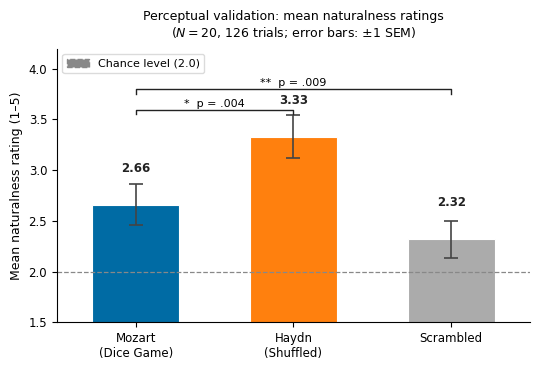

Saved: /content/drive/MyDrive/NEWDiceForClarinet/output/fig_perceptual.png


In [1]:
# ══════════════════════════════════════════════════════════════
# Figure: Perceptual Study Results
# Bar chart: Mozart vs Haydn vs Scrambled
# Mean rating + error bars
# ══════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Data from Colab original results (N=20, 126 trials) ───────
CONDITIONS = ['Mozart\n(Dice Game)', 'Haydn\n(Shuffled)', 'Scrambled']
MEANS      = [2.66, 3.33, 2.32]
# Approximate SDs from original analysis
SDS        = [0.89, 0.95, 0.82]
N          = 20
SEMS       = [s / np.sqrt(N) for s in SDS]

# ── Colors (colorblind-friendly: tableau-colorblind10) ─────────
COLORS = ['#006BA4', '#FF800E', '#ABABAB']  # blue, orange, grey

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 3.8))

x     = np.arange(len(CONDITIONS))
bars  = ax.bar(x, MEANS, color=COLORS, width=0.55,
               edgecolor='white', linewidth=0.8,
               yerr=SEMS, capsize=5, error_kw={
                   'elinewidth': 1.2,
                   'ecolor': '#444444',
                   'capthick': 1.2
               })

# Significance brackets
def sig_bracket(ax, x1, x2, y, text, dy=0.05):
    ax.plot([x1, x1, x2, x2],
            [y, y+dy, y+dy, y], lw=1.0, c='#222222')
    ax.text((x1+x2)/2, y+dy+0.01, text,
            ha='center', va='bottom', fontsize=8)

# Mozart vs Scrambled: p=0.009 **
sig_bracket(ax, 0, 2, 3.75, '**  p = .009')
# Mozart vs Haydn: p=0.004
sig_bracket(ax, 0, 1, 3.55, '*  p = .004', dy=0.04)

# Chance line
ax.axhline(y=2.0, color='#888888', linestyle='--',
           linewidth=0.9, label='Chance level (2.0)')

# Mean value labels
for bar, mean in zip(bars, MEANS):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(SEMS) + 0.08,
            f'{mean:.2f}',
            ha='center', va='bottom', fontsize=8.5,
            fontweight='bold', color='#222222')

ax.set_xticks(x)
ax.set_xticklabels(CONDITIONS, fontsize=9)
ax.set_ylabel('Mean naturalness rating (1–5)', fontsize=9)
ax.set_ylim(1.5, 4.2)
ax.set_xlim(-0.5, 2.5)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=8.5)

# Legend
chance_line = mpatches.Patch(color='#888888',
                              label='Chance level (2.0)',
                              linestyle='--', fill=False)
ax.legend(handles=[
    mpatches.Patch(color='#888888', linestyle='--',
                   label='Chance level (2.0)')],
    fontsize=8, loc='upper left',
    framealpha=0.7)

ax.set_title('Perceptual validation: mean naturalness ratings\n'
             r'($N=20$, 126 trials; error bars: $\pm$1 SEM)',
             fontsize=9, pad=8)

plt.tight_layout()
OUT = '/content/drive/MyDrive/NEWDiceForClarinet/output/fig_perceptual.png'
plt.savefig(OUT, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {OUT}")

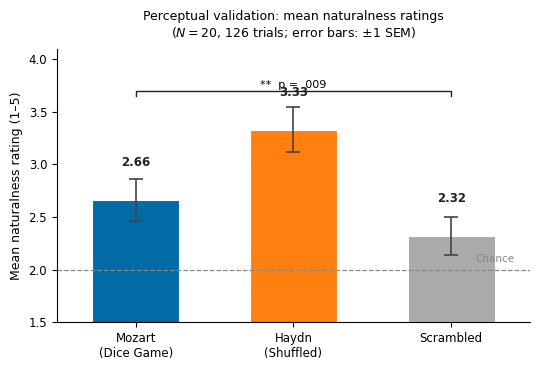

Saved: /content/drive/MyDrive/NEWDiceForClarinet/output/fig_perceptual.png


In [3]:
# ── Plot (Mozart vs Scrambled bracket only) ────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

CONDITIONS = ['Mozart\n(Dice Game)', 'Haydn\n(Shuffled)', 'Scrambled']
MEANS      = [2.66, 3.33, 2.32]
SDS        = [0.89, 0.95, 0.82]
N          = 20
SEMS       = [s / np.sqrt(N) for s in SDS]
COLORS     = ['#006BA4', '#FF800E', '#ABABAB']

fig, ax = plt.subplots(figsize=(5.5, 3.8))
x    = np.arange(len(CONDITIONS))
bars = ax.bar(x, MEANS, color=COLORS, width=0.55,
              edgecolor='white', linewidth=0.8,
              yerr=SEMS, capsize=5, error_kw={
                  'elinewidth': 1.2,
                  'ecolor': '#444444',
                  'capthick': 1.2
              })

# Mozart vs Scrambled only
def sig_bracket(ax, x1, x2, y, text, dy=0.05):
    ax.plot([x1, x1, x2, x2],
            [y, y+dy, y+dy, y], lw=1.0, c='#222222')
    ax.text((x1+x2)/2, y+dy+0.01, text,
            ha='center', va='bottom', fontsize=8)

sig_bracket(ax, 0, 2, 3.65, '**  p = .009')

ax.axhline(y=2.0, color='#888888', linestyle='--',
           linewidth=0.9)

for bar, mean in zip(bars, MEANS):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(SEMS) + 0.08,
            f'{mean:.2f}',
            ha='center', va='bottom', fontsize=8.5,
            fontweight='bold', color='#222222')

ax.set_xticks(x)
ax.set_xticklabels(CONDITIONS, fontsize=9)
ax.set_ylabel('Mean naturalness rating (1–5)', fontsize=9)
ax.set_ylim(1.5, 4.1)
ax.set_xlim(-0.5, 2.5)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=8.5)

ax.text(2.4, 2.05, 'Chance', fontsize=7.5,
        color='#888888', va='bottom', ha='right')

ax.set_title('Perceptual validation: mean naturalness ratings\n'
             r'($N=20$, 126 trials; error bars: $\pm$1 SEM)',
             fontsize=9, pad=8)

plt.tight_layout()
OUT = '/content/drive/MyDrive/NEWDiceForClarinet/output/fig_perceptual.png'
plt.savefig(OUT, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {OUT}")